In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import make_circles

In [2]:
samples = 1000

X, y = make_circles(
    samples,
    noise=0.03,
    random_state=42
)

print(X[:5])
print(y[:5])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
[1 1 1 1 0]


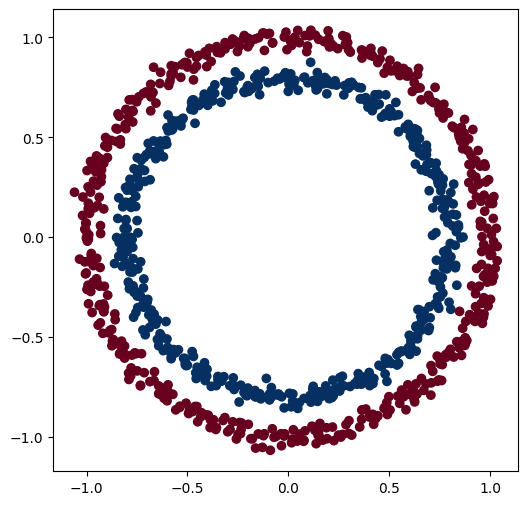

In [3]:
plt.figure(figsize=(6,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="RdBu"
)

plt.show()

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

In [5]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(
        from_logits=True
    ),
    optimizer="SGD",
    metrics=["accuracy"]
)

In [6]:
history = model.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

In [7]:
model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 0.6931


[0.6931469440460205, 0.5]

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [9]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [10]:
history = model.fit(
    X,
    y,
    epochs=500,
    verbose=0
)

In [11]:
def plot_decision_boundary(model, X, y):

    x_min, x_max = X[:,0].min()-0.1, X[:,0].max()+0.1
    y_min, y_max = X[:,1].min()-0.1, X[:,1].max()+0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    x_in = np.c_[xx.ravel(), yy.ravel()]

    y_pred = model.predict(x_in, verbose=0)

    y_pred = np.round(y_pred)

    y_pred = y_pred.reshape(xx.shape)

    plt.contourf(xx, yy, y_pred, alpha=0.7)

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y
    )

    plt.show()

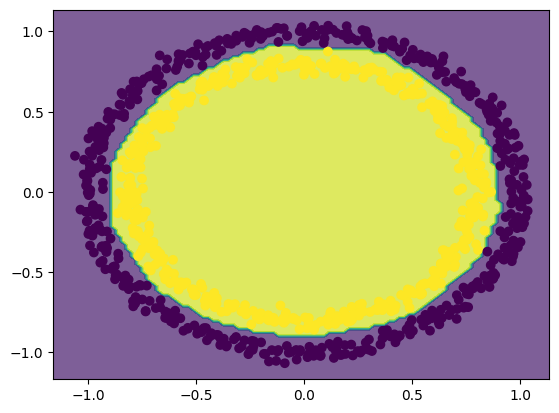

In [12]:
plot_decision_boundary(
    model,
    X,
    y
)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model.fit(
    X_train,
    y_train,
    epochs=500,
    verbose=0
)

In [15]:
loss, acc = model.evaluate(
    X_test,
    y_test
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 7.9761e-04 


In [16]:
print("Loss :", loss)
print("Accuracy :", acc)

Loss : 0.0007976128254085779
Accuracy : 1.0


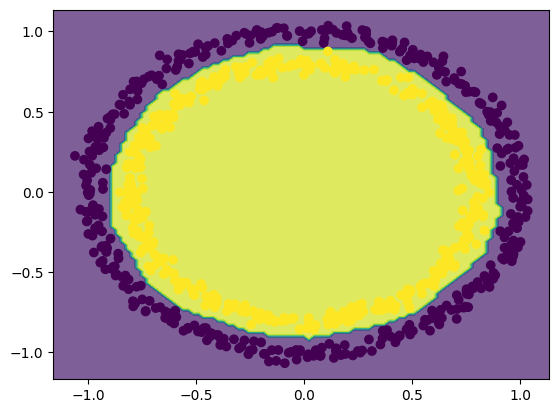

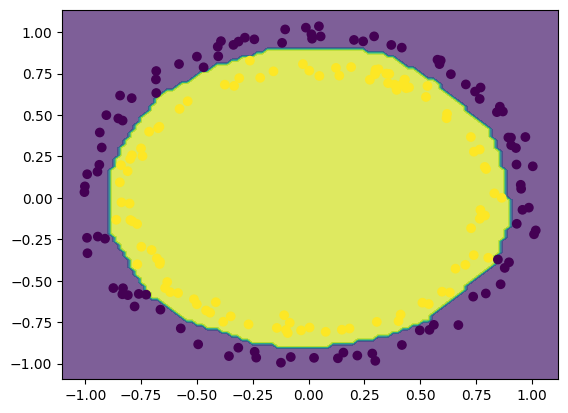

In [17]:
plot_decision_boundary(
    model,
    X_train,
    y_train
)

plot_decision_boundary(
    model,
    X_test,
    y_test
)